In [11]:
import pandas as pd

BASE = "vendas_produtos_trimestres.csv"

dados = pd.read_csv(BASE)

dados


,produto_id,produto_nome,vendas_T1,vendas_T2,vendas_T3,vendas_T4,despesas_T1,despesas_T2,despesas_T3,despesas_T4
0,1,Produto A,14499,24847,18720,26298,17779,8576,8978,14173
1,2,Produto B,16672,15275,12837,23786,11650,14201,18199,13572
2,3,Produto C,19332,29591,19245,16148,9435,14055,14165,17485
3,4,Produto D,24457,19382,12464,26894,15352,9769,12313,18657
4,5,Produto E,18822,23977,26087,26793,19512,12423,9400,19583


In [12]:
dados.columns

Index(['produto_id', 'produto_nome', 'vendas_T1', 'vendas_T2', 'vendas_T3',
       'vendas_T4', 'despesas_T1', 'despesas_T2', 'despesas_T3',
       'despesas_T4'],
      dtype='object')

In [13]:
dados.index

RangeIndex(start=0, stop=5, step=1)

In [14]:
dados_long = pd.wide_to_long(
    dados,
    stubnames=['vendas','despesas'],
    i=['produto_id','produto_nome'],
    j='trimestre',
    sep="_",
    suffix=r'\w+'
)

dados_long

vendas  despesas
produto_id produto_nome trimestre                  
1          Produto A    T1          14499     17779
                        T2          24847      8576
                        T3          18720      8978
                        T4          26298     14173
2          Produto B    T1          16672     11650
                        T2          15275     14201
                        T3          12837     18199
                        T4          23786     13572
3          Produto C    T1          19332      9435
                        T2          29591     14055
                        T3          19245     14165
                        T4          16148     17485
4          Produto D    T1          24457     15352
                        T2          19382      9769
                        T3          12464     12313
                        T4          26894     18657
5          Produto E    T1          18822     19512
                        T2          23977     12423
                        T3          26087      9400
                        T4          26793     19583

In [15]:
dados_long.index

MultiIndex([(1, 'Produto A', 'T1'),
            (1, 'Produto A', 'T2'),
            (1, 'Produto A', 'T3'),
            (1, 'Produto A', 'T4'),
            (2, 'Produto B', 'T1'),
            (2, 'Produto B', 'T2'),
            (2, 'Produto B', 'T3'),
            (2, 'Produto B', 'T4'),
            (3, 'Produto C', 'T1'),
            (3, 'Produto C', 'T2'),
            (3, 'Produto C', 'T3'),
            (3, 'Produto C', 'T4'),
            (4, 'Produto D', 'T1'),
            (4, 'Produto D', 'T2'),
            (4, 'Produto D', 'T3'),
            (4, 'Produto D', 'T4'),
            (5, 'Produto E', 'T1'),
            (5, 'Produto E', 'T2'),
            (5, 'Produto E', 'T3'),
            (5, 'Produto E', 'T4')],
           names=['produto_id', 'produto_nome', 'trimestre'])

In [16]:
dados_long = pd.wide_to_long(
    dados,
    stubnames=['vendas','despesas'],
    i=['produto_id','produto_nome'],
    j='trimestre',
    sep="_",
    suffix=r'\w+'
).reset_index()

dados_long

,produto_id,produto_nome,trimestre,vendas,despesas
0,1,Produto A,T1,14499,17779
1,1,Produto A,T2,24847,8576
2,1,Produto A,T3,18720,8978
3,1,Produto A,T4,26298,14173
4,2,Produto B,T1,16672,11650
5,2,Produto B,T2,15275,14201
6,2,Produto B,T3,12837,18199
7,2,Produto B,T4,23786,13572
8,3,Produto C,T1,19332,9435
9,3,Produto C,T2,29591,14055


In [20]:
dados_long["lucro"] = dados_long["vendas"] - dados_long["despesas"]

dados_long

,produto_id,produto_nome,trimestre,vendas,despesas,lucro
0,1,Produto A,T1,14499,17779,-3280
1,1,Produto A,T2,24847,8576,16271
2,1,Produto A,T3,18720,8978,9742
3,1,Produto A,T4,26298,14173,12125
4,2,Produto B,T1,16672,11650,5022
5,2,Produto B,T2,15275,14201,1074
6,2,Produto B,T3,12837,18199,-5362
7,2,Produto B,T4,23786,13572,10214
8,3,Produto C,T1,19332,9435,9897
9,3,Produto C,T2,29591,14055,15536


In [18]:
dados_long.groupby("produto_nome")[['vendas','despesas','lucro']].sum()

,vendas,despesas,lucro
produto_nome,,,
Produto A,84364,49506,34858
Produto B,68570,57622,10948
Produto C,84316,55140,29176
Produto D,83197,56091,27106
Produto E,95679,60918,34761


In [22]:
dados_long.groupby("trimestre")[['vendas','despesas','lucro']].sum()

,vendas,despesas,lucro
trimestre,,,
T1,93782,73728,20054
T2,113072,59024,54048
T3,89353,63055,26298
T4,119919,83470,36449


<Axes: xlabel='produto_nome'>

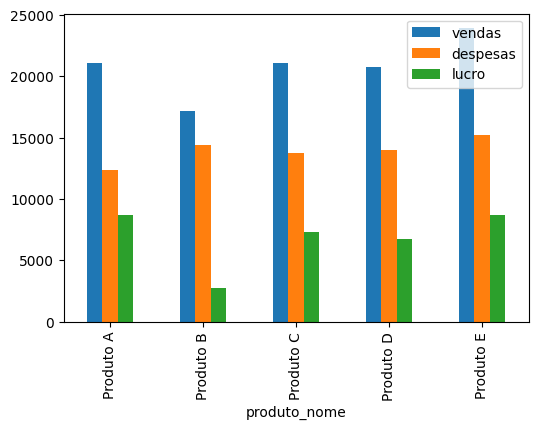

In [24]:
dados_long.groupby("produto_nome")[["vendas","despesas","lucro"]].mean(

).plot(kind="bar",figsize=(6,4))

<Axes: xlabel='produto_nome'>

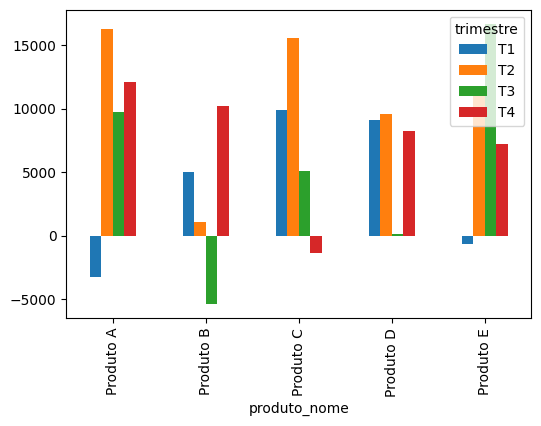

In [26]:
dados_long.pivot_table(
    index="produto_nome", columns="trimestre", values="lucro",aggfunc="mean").plot(kind="bar",figsize=(6,4                                                                                                       ))